In [3]:
pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -------------------- ------------------- 5.0/9.6 MB 21.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 29.8 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ---------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os, json, requests, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL

from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [5]:
DATASET_KEY = "realKnownCause/machine_temperature_system_failure.csv"

data_url = f"https://raw.githubusercontent.com/numenta/NAB/master/data/{DATASET_KEY}"
label_url = "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_windows.json"

os.makedirs("data", exist_ok=True)

df = pd.read_csv(data_url, parse_dates=["timestamp"])
windows = requests.get(label_url).json()[DATASET_KEY]

df["label"] = 0
for start, end in windows:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    df.loc[df["timestamp"].between(start, end), "label"] = 1

df.head()

,timestamp,value,label
0,2013-12-02 21:15:00,73.967322,0
1,2013-12-02 21:20:00,74.935882,0
2,2013-12-02 21:25:00,76.124162,0
3,2013-12-02 21:30:00,78.140707,0
4,2013-12-02 21:35:00,79.329836,0


### Phase 1: EDA

In [ ]:

print(df.shape)
print(df.head())
print(df["label"].value_counts())

stats = {
    "mean": df["value"].mean(),
    "std": df["value"].std(),
    "skewness": skew(df["value"]),
    "min": df["value"].min(),
    "max": df["value"].max(),
}
stats

(22695, 3)
            timestamp      value  label
0 2013-12-02 21:15:00  73.967322      0
1 2013-12-02 21:20:00  74.935882      0
2 2013-12-02 21:25:00  76.124162      0
3 2013-12-02 21:30:00  78.140707      0
4 2013-12-02 21:35:00  79.329836      0
label
0    20427
1     2268
Name: count, dtype: int64


{'mean': 85.92649821068021,
 'std': 13.746912473090102,
 'skewness': -1.8336859840742736,
 'min': 2.084721206,
 'max': 108.5105428}

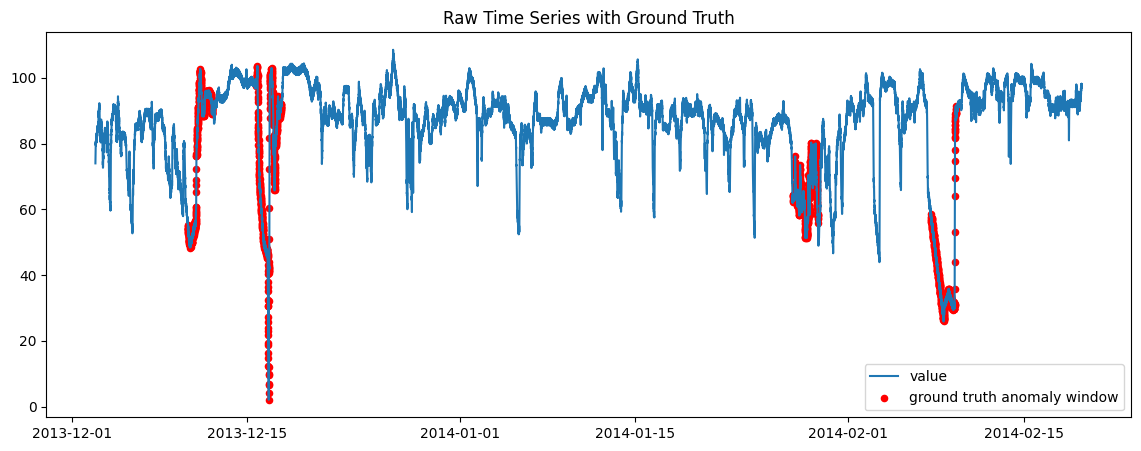

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["value"], label="value")
plt.scatter(
    df.loc[df["label"] == 1, "timestamp"],
    df.loc[df["label"] == 1, "value"],
    color="red",
    s=20,
    label="ground truth anomaly window"
)
plt.title("Raw Time Series with Ground Truth")
plt.legend()
plt.show()

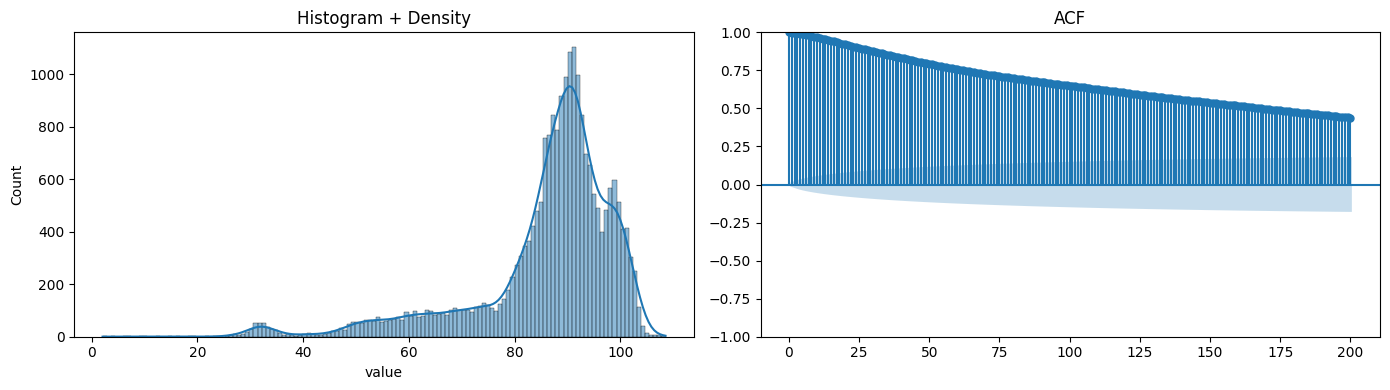

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["value"], kde=True, ax=ax[0])
ax[0].set_title("Histogram + Density")

plot_acf(df["value"], lags=200, ax=ax[1])
ax[1].set_title("ACF")

plt.tight_layout()
plt.show()

<Figure size 1400x400 with 0 Axes>

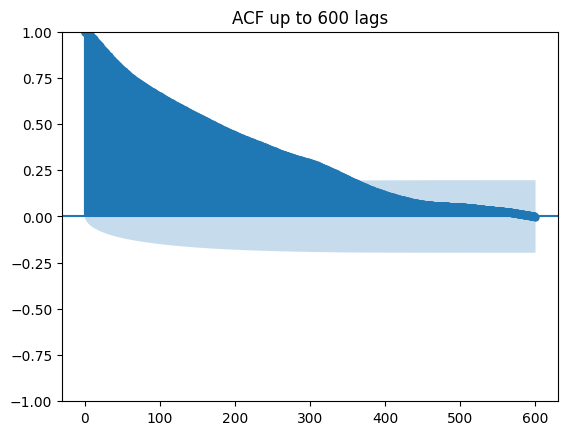

In [9]:
plt.figure(figsize=(14, 4))
plot_acf(df["value"], lags=600)
plt.title("ACF up to 600 lags")
plt.show()

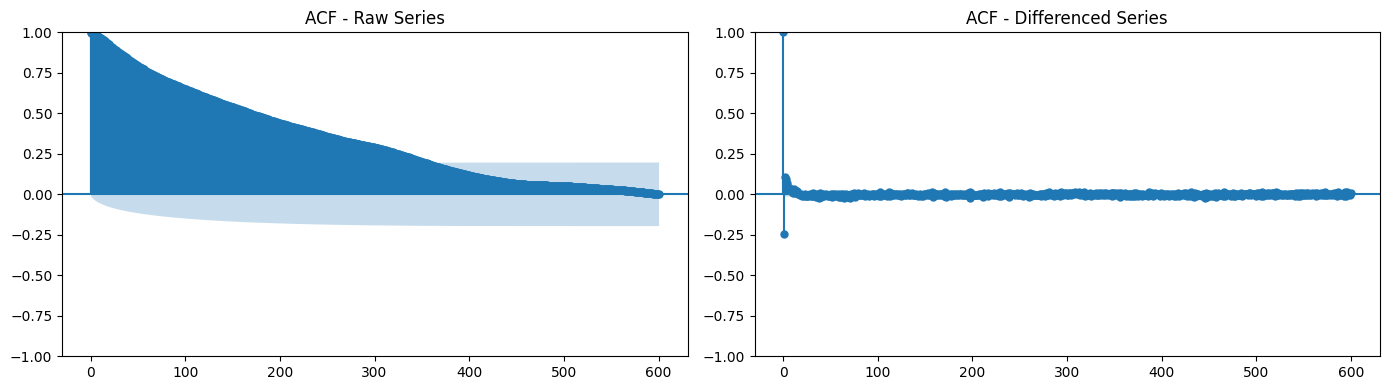

In [10]:
# Differencing để giảm trend / non-stationary behavior
df["value_diff"] = df["value"].diff()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["value"].dropna(), lags=600, ax=ax[0])
ax[0].set_title("ACF - Raw Series")

plot_acf(df["value_diff"].dropna(), lags=600, ax=ax[1])
ax[1].set_title("ACF - Differenced Series")

plt.tight_layout()
plt.show()

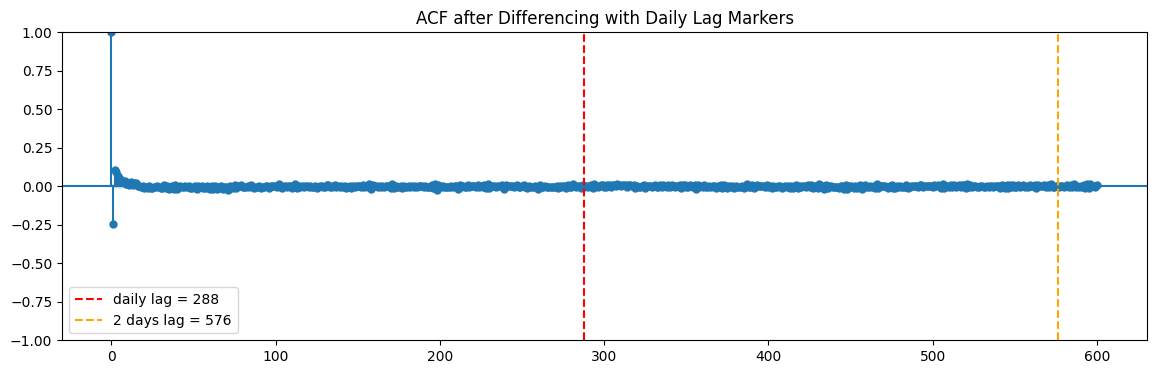

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(df["value_diff"].dropna(), lags=600, ax=ax)
ax.axvline(288, color="red", linestyle="--", label="daily lag = 288")
ax.axvline(576, color="orange", linestyle="--", label="2 days lag = 576")
ax.set_title("ACF after Differencing with Daily Lag Markers")
ax.legend()
plt.show()

## Phase 2

### Helper

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def evaluate_detector(y_true, y_pred, name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "detector": name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarms": fp,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

### Detector 1 - IQR

In [36]:
def iqr_detector(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr

    y_pred = ((series < lower_bound) | (series > upper_bound)).astype(int)

    return y_pred, lower_bound, upper_bound

In [37]:
iqr_pred, iqr_lower, iqr_upper = iqr_detector(df["value"], k=1.5)

iqr_result = evaluate_detector(
    y_true=df["label"],
    y_pred=iqr_pred,
    name="IQR Detector"
)
iqr_result

{'detector': 'IQR Detector',
 'precision': 0.5800696257615318,
 'recall': 0.5877425044091711,
 'f1': 0.5838808585194919,
 'false_alarms': 965,
 'tp': 1333,
 'fp': 965,
 'fn': 935,
 'tn': 19462}

IQR được chọn vì EDA cho thấy dữ liệu bị left-skewed mạnh và không Gaussian. IQR không phụ thuộc vào mean/std nên robust hơn với skewed data và outlier.

### Tạo feature table cho Isolation Forest

In [38]:
def build_features(df, window=60):
    s = df["value"]

    features = pd.DataFrame({
        "value": s,
        "rolling_mean": s.rolling(window).mean(),
        "rolling_std": s.rolling(window).std(),
        "rolling_min": s.rolling(window).min(),
        "rolling_max": s.rolling(window).max(),
        "rate_of_change": s.diff(),
        "lag_1": s.shift(1),
        "lag_window": s.shift(window),
        "z_score": (s - s.rolling(window).mean()) / s.rolling(window).std(),
        "hour": df["timestamp"].dt.hour,
        "dayofweek": df["timestamp"].dt.dayofweek,
    })

    features = features.replace([np.inf, -np.inf], np.nan).dropna()
    return features

In [39]:
X = build_features(df, window=60)
y_true_if = df.loc[X.index, "label"]

print(X.shape)
X.head()

(22635, 11)


,value,rolling_mean,rolling_std,rolling_min,rolling_max,rate_of_change,lag_1,lag_window,z_score,hour,dayofweek
60,84.834840,82.085035,2.269469,74.935882,85.437842,-0.603002,85.437842,73.967322,1.211652,2,1
61,84.947158,82.251889,2.096364,76.124162,85.437842,0.112318,84.834840,74.935882,1.285688,2,1
62,86.168619,82.419297,1.997456,78.140707,86.168619,1.221461,84.947158,76.124162,1.877049,2,1
63,86.376219,82.556555,1.981356,78.710418,86.376219,0.207600,86.168619,78.140707,1.927803,2,1
64,86.342168,82.673427,1.994569,78.710418,86.376219,-0.034050,86.376219,79.329836,1.839365,2,1


###  Tune Isolation Forest contamination

In [40]:
from sklearn.ensemble import IsolationForest

contamination_values = [0.01, 0.02, 0.05]
if_tuning_results = []

for contamination in contamination_values:
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )

    raw_pred = model.fit_predict(X)

    # scikit-learn convention:
    # -1 = anomaly, 1 = normal
    y_pred_if = (raw_pred == -1).astype(int)

    result = evaluate_detector(
        y_true=y_true_if,
        y_pred=y_pred_if,
        name=f"Isolation Forest contamination={contamination}"
    )

    result["contamination"] = contamination
    if_tuning_results.append(result)

if_tuning_df = pd.DataFrame(if_tuning_results)
if_tuning_df[["contamination", "precision", "recall", "f1", "false_alarms", "tp", "fp", "fn"]]

,contamination,precision,recall,f1,false_alarms,tp,fp,fn
0,0.01,1.000000,0.100088,0.181964,0,227,0,2041
1,0.02,0.986755,0.197090,0.328556,6,447,6,1821
2,0.05,0.760601,0.379630,0.506471,271,861,271,1407


Contamination là giả định tỉ lệ anomaly trong dữ liệu. Khi contamination tăng, model thường đánh dấu nhiều điểm là anomaly hơn. Điều này có thể tăng recall nhưng cũng dễ làm tăng false alarms và giảm precision.

###  Train Isolation Forest tốt nhất

In [41]:
best_row = if_tuning_df.sort_values("f1", ascending=False).iloc[0]
best_contamination = best_row["contamination"]

best_contamination

0.05

In [42]:
best_if_model = IsolationForest(
    n_estimators=100,
    contamination=best_contamination,
    random_state=42
)

best_if_raw_pred = best_if_model.fit_predict(X)
best_if_pred = (best_if_raw_pred == -1).astype(int)

joblib.dump(best_if_model, "isolation_forest_model.joblib")
os.path.getsize("isolation_forest_model.joblib") / 1024

1191.8037109375

In [43]:
import joblib
import os

joblib.dump(best_if_model, "isolation_forest_model.joblib")

model_size_kb = os.path.getsize("isolation_forest_model.joblib") / 1024
model_size_kb

1191.8037109375

### Plot 2 detector

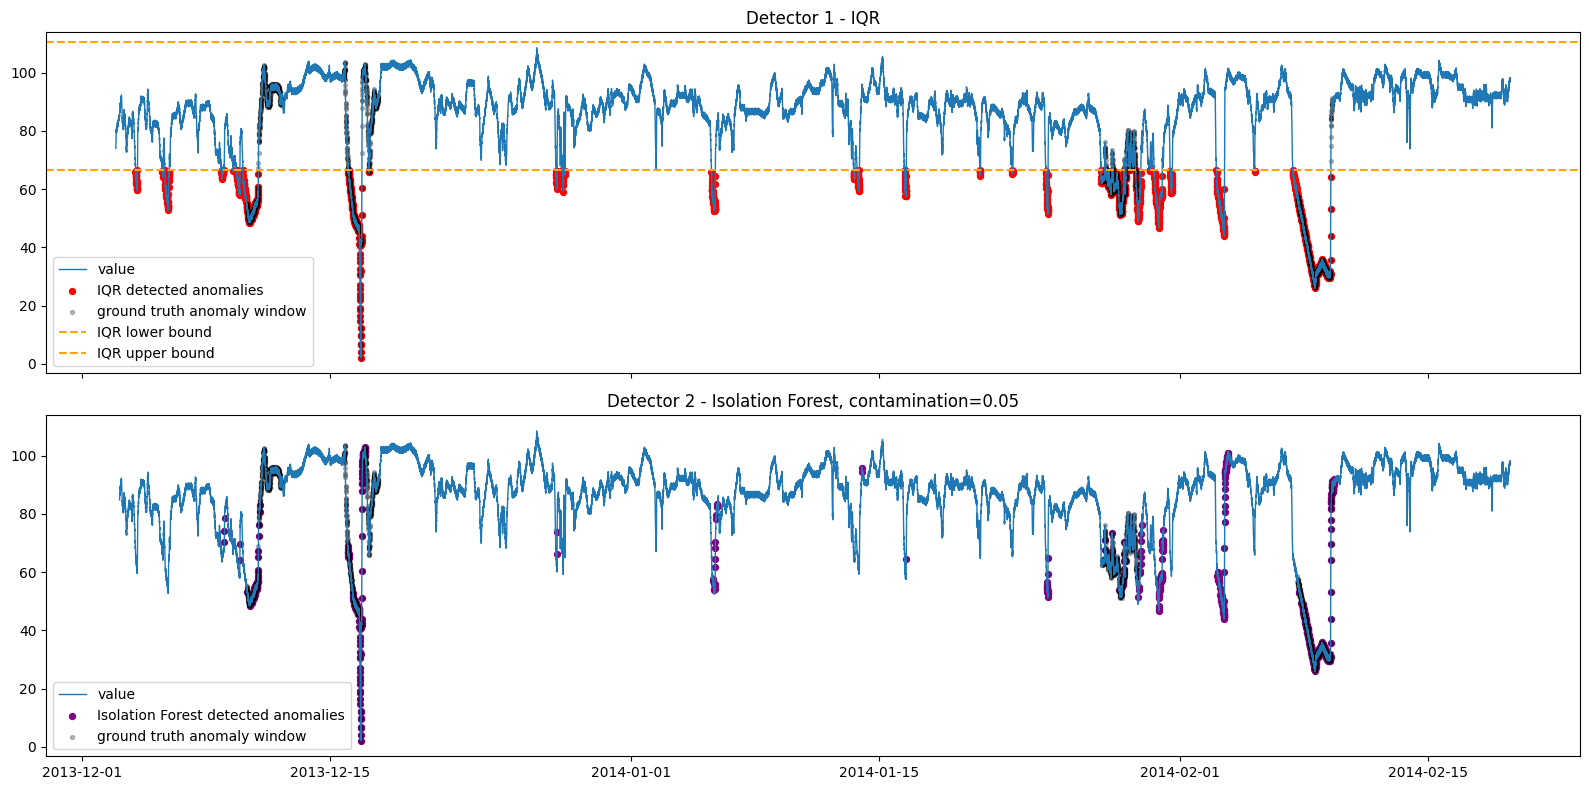

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Detector 1: IQR
axes[0].plot(df["timestamp"], df["value"], label="value", linewidth=1)
axes[0].scatter(
    df.loc[iqr_pred == 1, "timestamp"],
    df.loc[iqr_pred == 1, "value"],
    color="red",
    s=18,
    label="IQR detected anomalies"
)
axes[0].scatter(
    df.loc[df["label"] == 1, "timestamp"],
    df.loc[df["label"] == 1, "value"],
    color="black",
    s=8,
    alpha=0.25,
    label="ground truth anomaly window"
)
axes[0].axhline(iqr_lower, color="orange", linestyle="--", label="IQR lower bound")
axes[0].axhline(iqr_upper, color="orange", linestyle="--", label="IQR upper bound")
axes[0].set_title("Detector 1 - IQR")
axes[0].legend()

# Detector 2: Isolation Forest
if_plot_df = df.loc[X.index].copy()
if_plot_df["if_pred"] = best_if_pred

axes[1].plot(if_plot_df["timestamp"], if_plot_df["value"], label="value", linewidth=1)
axes[1].scatter(
    if_plot_df.loc[if_plot_df["if_pred"] == 1, "timestamp"],
    if_plot_df.loc[if_plot_df["if_pred"] == 1, "value"],
    color="purple",
    s=18,
    label="Isolation Forest detected anomalies"
)
axes[1].scatter(
    if_plot_df.loc[if_plot_df["label"] == 1, "timestamp"],
    if_plot_df.loc[if_plot_df["label"] == 1, "value"],
    color="black",
    s=8,
    alpha=0.25,
    label="ground truth anomaly window"
)
axes[1].set_title(f"Detector 2 - Isolation Forest, contamination={best_contamination}")
axes[1].legend()

plt.tight_layout()
plt.savefig("phase2_anomaly_detection_results.png", dpi=160)
plt.show()

## Phase 3: So sánh & Đánh giá

Phần này so sánh hai phương pháp phát hiện bất thường (IQR và Isolation Forest) thông qua các chỉ số:

Precision
Recall
F1-Score
False Alarms (cảnh báo nhầm)

Kết quả quá trình tinh chỉnh tham số contamination của Isolation Forest được lưu trong file if_tuning_log.csv.

Bảng tổng hợp kết quả so sánh giữa các detector được lưu trong file phase2_comparison.csv.

Nhận xét
- IQR đạt Recall và F1-Score cao hơn, nghĩa là phát hiện được nhiều khoảng thời gian xảy ra bất thường (anomaly windows) hơn.
- Isolation Forest có Precision cao hơn và số lượng False Alarms thấp hơn, nghĩa là ít báo động nhầm hơn nhưng cũng bỏ sót nhiều bất thường hơn.
- Nếu ưu tiên không bỏ sót sự cố (dù chấp nhận nhiều cảnh báo hơn), nên chọn IQR hoặc tăng giá trị contamination của Isolation Forest để cải thiện Recall.
- Nếu ưu tiên giảm nhiễu cảnh báo cho đội on-call, nên chọn Isolation Forest vì có Precision cao hơn và ít cảnh báo nhầm hơn.

In [45]:
phase2_comparison = pd.DataFrame([iqr_result, if_result])
phase2_comparison[["detector", "precision", "recall", "f1", "false_alarms", "tp", "fp", "fn"]]

,detector,precision,recall,f1,false_alarms,tp,fp,fn
0,IQR Detector,0.580070,0.587743,0.583881,965,1333,965,935
1,Isolation Forest best contamination=0.05,0.760601,0.379630,0.506471,271,861,271,1407


In [46]:
phase2_comparison.to_csv("phase2_comparison.csv", index=False)
if_tuning_df.to_csv("if_tuning_log.csv", index=False)